# Sheet 1 - Models of Neural Systems - Computer Practical
#### Group members : Abed Al Karim Taha, Rezwana Hussainzada, Salva Vali Zadeh
##### AI usage : "AI tools have been used to review this solution"


### McCulloch-Pitts Neurons and Perceptron Learning
This assignment revolves around the simple model proposed by McCulloch and pitts (1943): a perceptron with a binary activation function Historically, this model provided the first simplification of biological neurons as computational units. Here, we will show one such neuron can be trained by supervised learning, to perform real-world computations. Afterwards, we will also explore its limitations.

#### 1-McCulloch-Pitts Neuron

(a) Implement a McCulloch-Pitts neuron :
$$y(x) = sgn (w^T x)$$

$$sgn(x) =
\begin{cases}
+1, \ \ \text{if } x > 0\\
-1, \ \ \text{if } x \le 0~
\end{cases}$$

Where $x = [-1, x_1,x_2, ..., x_k]$ is a vector of inputs, $w = [w_0, w_1, w_2, ..., w_k]$ is a vector of weights and $y(x)$ is the output. Note that the first input $x_0$ is always -1, because $w_0$ represents the "bias term" (threshold $\theta$ in the lecture.)

Solution:
$$y(x) = sgn(w^Tx) = \Sigma_{i =1}^{k}w_ix_i-w_0$$



(b) Take weights $w = [3, 2, 2]$ and two binary inputs $x_1, x_2 \in \{−1, +1\}$. Show that the neuron performs a logical AND operation.


In [ ]:
w = [3, 2, 2]                     # weights: w0 (bias), w1, w2

# x = [x0, x1, x2], where x0 = -1 represents the bias input

def y(x, w):
    sum = 0
    for i in range(len(w)):
        sum += w[i] * x[i]        # accumulate weighted inputs
    return sum

def sgn(x):
    return 1 if x > 0 else -1     # sign function

S = [[1,1], [1,-1], [-1,1], [-1,-1]]   # all possible input pairs (x1, x2)

inputs = []

for n in range(len(S)):
    x = [-1, S[n][0], S[n][1]]
    inputs.append(x)               # store input vector

for x in inputs:
    z = sgn(y(x, w))
    print(f"x = {x} --> y = {z}")  # display input and its corresponding output


This is exactly like the value table of AND operation.

#### 2-Activation functions
Often, the step function (as used in McCulloch-Pitts neuron) is too crude for estimating the activity of a neuron as a function of its input. Plot the fllowing functions for the reasonable choices of the free parameter $a>0$. What is the meaning of the parameter a>0?

(a) Sigmoid functions:
$$f(x)=\frac{2}{1+exp(-ax)}-1$$
(b) Hyperbolic tangent function :
$$g(x) = tanh(ax)=\frac{exp(ax)-exp(-ax)}{exp(ax)+exp(-ax)}$$
(c) Piecewise linear function:
$$ l(x) =
\begin{cases}
1, \ \ \text{if } x>=\frac{1}{a}\\
ax, \ \ \text{if } -\frac{1}{a}<x<\frac{1}{a}\\
-1, \ \ \text{if } x<=\frac{1}{a}
\end{cases}
$$

Solution:

By choosing different values for 'a' we can show how its values affect the shape of the activation functions.
We know that these three functions are bounded, which their lower bound is -1 and upper bound is 1. Small 'a' makes the activation function more smooth which changes gradually from the lower bound to upper. But large 'a' makes the activation functions sharp in the transition phase, and they look like step functions. We choose $a = [0.5,1,5]$ a combination of small value (0.5), large value (5), and not too small and not too large value (1) to show their effects.

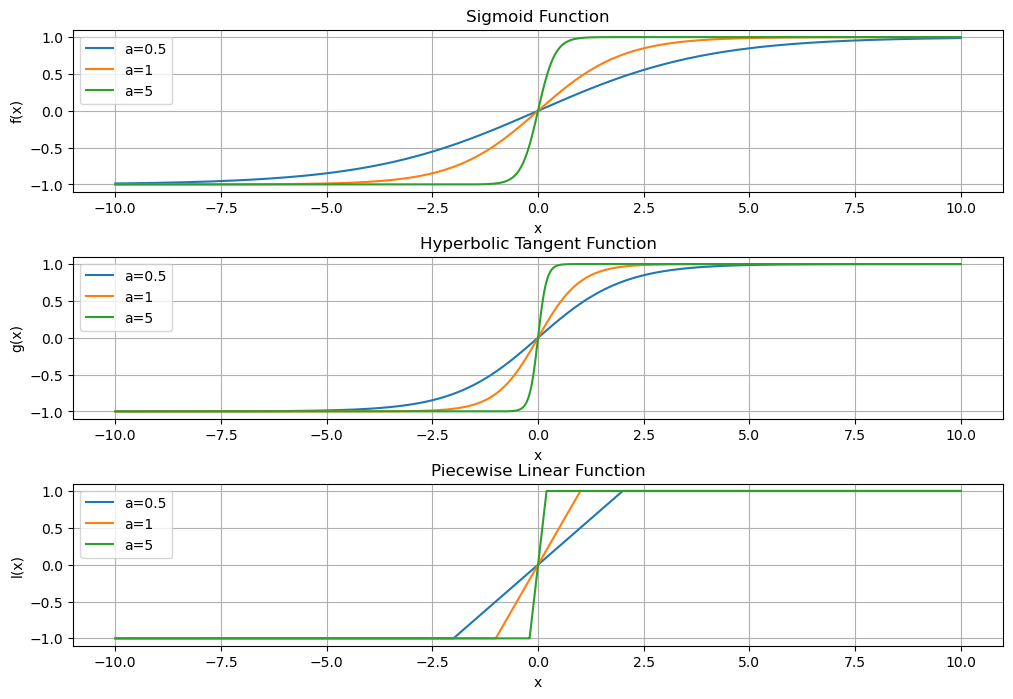

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, a):
    z = (2 / (1 + np.exp(-a * x))) - 1     # Sigmoid function scaled to [-1, 1]
    return z

def g(x, a):
    z = np.tanh(a * x)                     # Hyperbolic tangent function
    return z

def l(x, a):                                # Piecewise linear function
    if x >= 1/a:
        z = 1
    elif -1/a < x < 1/a:
        z = a * x
    elif x <= -1/a:
        z = -1
    return z


a_values = [0.5, 1, 5]                     #
x = np.linspace(-10, 10, 4000)             # Continuous range of x values

plt.figure(figsize=(12, 8))                # Set figure size

plt.subplot(3, 1, 1)                       # First subplot (row 1 of 3)
for a in a_values:
    plt.plot(x, f(x, a), label=f'a={a}')   # Plot for each a value
plt.title('Sigmoid Function')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)                       # Second subplot (row 2 of 3)
for a in a_values:
    plt.plot(x, g(x, a), label=f'a={a}')
plt.title('Hyperbolic Tangent Function')
plt.xlabel('x')
plt.ylabel('g(x)')
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)                       # Third subplot (row 3 of 3)
for a in a_values:
    l_x = [l(x[i], a) for i in range(len(x))]  # Compute l(x) for all x values
    plt.plot(x, l_x, label=f'a={a}')
plt.title('Piecewise Linear Function')
plt.xlabel('x')
plt.ylabel('l(x)')
plt.grid(True)
plt.legend()

plt.subplots_adjust(hspace=0.4)            # Add vertical space between plots
plt.show()                                 # Display all figures


How can you choose 'a', to obtain the step function from any of the three functions?

$$ h(x) =
\begin{cases}
1 \ \ \ \ \ \text{if } x>=0\\
-1 \ \ \ \ \text{if } x<0
\end{cases}
$$
Solution:
By choosing a very large 'a' we can approximate three activation functions with the step function.

#### 3- Rosenblatt’s perceptron

(a) Prepare a training set $\{x_i, d(x_i)\}$ for $i = 1, 2, . . . , 1000$, where $x_i = [−1, x_{i,1}, x_{i,2}]$ is an input vector with random values $x_{i,1}$ and $x_{i,2}$ drawn from a standard normal distribution, and $d(x)$
is the desired response. Let the desired response be a comparison between the coordinates $x_1$ and $x_2$:

$$ d(x) =
\begin{cases}
1 \ \ \ \ \text{if } x_2-x_1>=0.5\\
-1 \ \ \ \ \text{if } x_2-x_1<0.5
\end{cases}
$$


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Number of inputs
n = 1000

# Generate x_1 and x_2 from standard normal distribution
x_1 = np.random.randn(n)
x_2 = np.random.randn(n)

inputs = []
for i in range(n):
    z = [-1, x_1[i], x_2[i]]
    inputs.append(z)

def dx(x_1, x_2):
    if x_2 - x_1 >= 0.5:
        z = 1
    elif x_2 - x_1 < 0.5:
        z = -1
    return z

training_set = [(inputs[i], dx(inputs[i][1], inputs[i][2])) for i in range(n)]

#  Added line to show how many training samples were created
print("Number of training samples:", len(training_set))

# Print the first 5 training pairs
for i in range(5):
    print(training_set[i])


Number of training samples: 1000
([-1, 1.8876876573401904, 0.47263034584340563], -1)
([-1, 0.5565531245337582, -1.3668583632808264], -1)
([-1, -1.3354815690998914, 0.5925672738473307], 1)
([-1, 0.486036289417637, -2.704391631602775], -1)
([-1, -1.5473039889383655, -0.6298845523638104], 1)


(b) Trian a McCulloch-Pitts neuron on the training set, by presenting all the examples iteratively and, after each example $x_i$, updating the weights using an error-correction update rule:

$$
w_{new} = w_{old}+\eta(d(x_i)-y(x_i))x_i
$$
where $\eta>0$ is the learning rate and $y(x)$ is the response of McCulloch-Pitts neuron, as defined in exercise 1:
$$
y(x) = sgn(w^Tx).
$$
One training “epoch” is completed when all examples have been presented once. At the end of each epoch, check whether, over this past epoch, any weights have been changed. Train the neuron over multiple epochs until no further weight changes occur.

In [6]:
# --- Rosenblatt's Perceptron Learning (Task 3b) ---

import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Create training data (same as 3a)
np.random.seed(42)                       # reproducibility
N = 1000                                 # number of samples
X = np.random.randn(N, 2)                # x1, x2 ~ N(0,1)

# Add bias term x0 = -1  → shape (N,3)
X_aug = np.hstack((-1*np.ones((N,1)), X))

# Desired output function: compare x2 - x1
def desired_output(x):
    return 1 if x[2] - x[1] >= 0.5 else -1

d = np.array([desired_output(x) for x in X_aug])

# 2️⃣ Initialize weights randomly (w0, w1, w2)
w = np.random.randn(3)

# Learning rate (η)
eta = 0.1

# Function to compute perceptron output
def perceptron_output(x, w):
    return 1 if np.dot(w, x) >= 0 else -1

# 3️⃣ Training loop
epoch = 0
changed = True

while changed:
    changed = False
    for i in range(N):
        y = perceptron_output(X_aug[i], w)
        if y != d[i]:
            w = w + eta * (d[i] - y) * X_aug[i]
            changed = True
    epoch += 1
    print(f"Epoch {epoch} completed")

print("\nTraining converged after", epoch, "epochs.")
print("Final weights:", w)


Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Epoch 21 completed
Epoch 22 completed
Epoch 23 completed
Epoch 24 completed
Epoch 25 completed
Epoch 26 completed
Epoch 27 completed
Epoch 28 completed
Epoch 29 completed
Epoch 30 completed
Epoch 31 completed
Epoch 32 completed
Epoch 33 completed
Epoch 34 completed
Epoch 35 completed
Epoch 36 completed
Epoch 37 completed
Epoch 38 completed
Epoch 39 completed
Epoch 40 completed
Epoch 41 completed
Epoch 42 completed
Epoch 43 completed
Epoch 44 completed
Epoch 45 completed
Epoch 46 completed
Epoch 47 completed
Epoch 48 completed
Epoch 49 completed
Epoch 50 completed
Epoch 51 completed
Epoch 52 completed
Epoch 53 completed
Ep

What values for $\eta$ do you use, and why? Is this learning rule biologically plausible (meaning, could this happen in a real neuron)? Why or why not?

Solution :
$\eta$=0.1. It is large enough to allow learning. If $\eta$ be too small the weight changes are tiny. the neuron will need many epochs to reach convergence. And if $\eta$ be too large, the step may overshoot the correct boundary and leads to unstable behavior.
But in real world neurons do not have a teacher as the training set to learn. They adapt their behavior to the mechanism of the effect of their neighbors on their activation. (Hebbian plasticity)

(c) Test on a new dataset (validation set) that the neuron can indeed perform the trained comparison
function.

In [7]:
# new dataset

import numpy as np

# New validation set size
m = 500

x_1_new = np.random.randn(m)
x_2_new = np.random.randn(m)

# Build augmented inputs [-1, x1, x2]
val_inputs = []
for i in range(m):
    z = [-1.0, x_1_new[i], x_2_new[i]]
    val_inputs.append(z)

# Desired output rule (same as training): +1 if x2 - x1 >= 0.5 else -1
def dx(x_1, x_2):
    if x_2 - x_1 >= 0.5:
        z = 1
    elif x_2 - x_1 < 0.5:
        z = -1
    return z

# Perceptron prediction using trained weights w (assumes w exists from 3(b))
def perceptron_output(x, w):
    s = w[0]*x[0] + w[1]*x[1] + w[2]*x[2]
    return 1 if s >= 0 else -1

# Evaluate on the validation set
correct = 0
for i in range(m):
    x = val_inputs[i]
    d = dx(x[1], x[2])
    y = perceptron_output(x, w)
    if y == d:
        correct += 1

accuracy = correct / m

print("Validation samples:", m)
print(accuracy)


Validation samples: 500
0.998


(d) Plot the training set and label each input vector according to its response class. Superimpose the weight vector on the same plot (think about the bias term w_0).

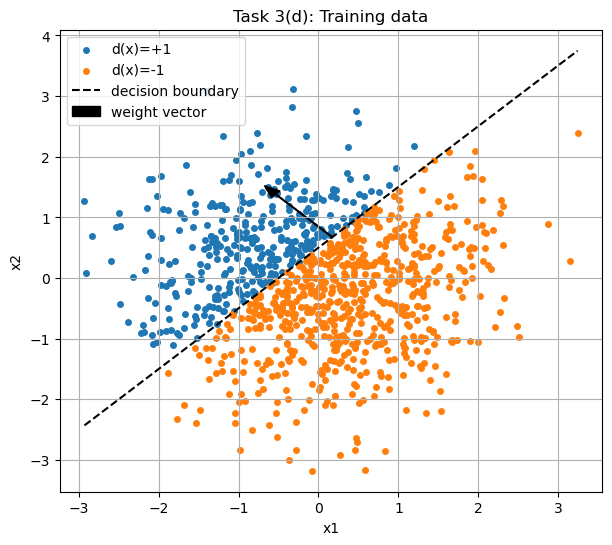

In [12]:
import numpy as np
import matplotlib.pyplot as plt

x1_pos, x2_pos = [], []
x1_neg, x2_neg = [], []

#  Detect what exists and loop correctly
if "X_aug" in locals() and isinstance(d, np.ndarray):
    N = len(d)
    for i in range(N):
        if d[i] == 1:
            x1_pos.append(X_aug[i][1]); x2_pos.append(X_aug[i][2])
        else:
            x1_neg.append(X_aug[i][1]); x2_neg.append(X_aug[i][2])
else:
    N = len(training_set)
    for i in range(N):
        x = training_set[i][0]
        lbl = training_set[i][1]
        if lbl == 1:
            x1_pos.append(x[1]); x2_pos.append(x[2])
        else:
            x1_neg.append(x[1]); x2_neg.append(x[2])

plt.figure(figsize=(7,6))
plt.scatter(x1_pos, x2_pos, s=16, label='d(x)=+1')
plt.scatter(x1_neg, x2_neg, s=16, label='d(x)=-1')

x1_min = min(x1_pos + x1_neg)
x1_max = max(x1_pos + x1_neg)
x1_vals = np.linspace(x1_min, x1_max, 200)
x2_vals = -(w[1]*x1_vals - w[0]) / w[2]
plt.plot(x1_vals, x2_vals, 'k--', label='decision boundary')

# weight vector arrow
start_x = x1_vals[100]
start_y = x2_vals[100]
norm_w = np.sqrt(w[1]**2 + w[2]**2)
dx = w[1] / (norm_w + 1e-12)
dy = w[2] / (norm_w + 1e-12)
plt.arrow(start_x, start_y, dx, dy, width=0.01, head_width=0.15,
          head_length=0.2, color='black', label='weight vector')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Task 3(d): Training data')
plt.legend()
plt.grid(True)
plt.show()


In what sense is this weight vector optimal? Why can this network be thought of as performing a generalized logical operation? And which one?
Soultion :
Logical operation which this network offer : output +1 if $x_2-x_1>=0.5$ and −1 otherwise.
#### 4-Linear separability
(a) Plot the XOR classification problem on an Euclidean plane. XOR is a logical operation whose truth table is (here 0 is considered equivalent to −1):


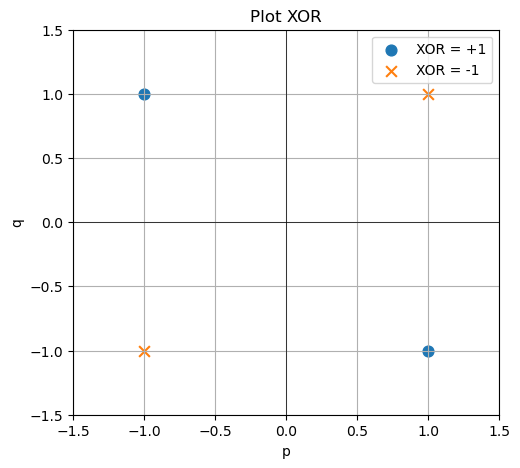

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Points: (p, q) ∈ {-1, +1} × {-1, +1}
# XOR labels: +1 if p != q,  -1 if p == q
data = [
    [-1, -1, -1],  # p=-1, q=-1 → XOR = 0 ≡ -1
    [-1, +1, +1],  # p=-1, q=+1 → XOR = 1 ≡ +1
    [+1, -1, +1],  # p=+1, q=-1 → XOR = 1 ≡ +1
    [+1, +1, -1],  # p=+1, q=+1 → XOR = 0 ≡ -1
]

# separate for plotting
x_pos, y_pos = [], []
x_neg, y_neg = [], []

for i in range(len(data)):
    p = data[i][0]
    q = data[i][1]
    lbl = data[i][2]
    if lbl == +1:
        x_pos.append(p); y_pos.append(q)
    else:
        x_neg.append(p); y_neg.append(q)

plt.figure(figsize=(5.5,5))
plt.scatter(x_pos, y_pos, s=60, label='XOR = +1', marker='o')
plt.scatter(x_neg, y_neg, s=60, label='XOR = -1', marker='x')
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.xlim(-1.5, 1.5); plt.ylim(-1.5, 1.5)
plt.xlabel('p'); plt.ylabel('q')
plt.title('Plot XOR')
plt.legend()
plt.grid(True)
plt.show()


(b) Train a perceptron to perform the XOR function on binary inputs. Show that the learning algorithm does not converge, i.e., the weights do not settle on fixed values. Can you explain why?

In [15]:
# training set with bias x0 = -1
# x = [-1, p, q], d = XOR(p,q) in {-1,+1}
train_X = []
train_d = []

for i in range(len(data)):
    p = data[i][0]
    q = data[i][1]
    lbl = data[i][2]       # XOR label in {-1,+1}
    train_X.append([-1, p, q])
    train_d.append(lbl)

# perceptron parameters
w = [0.0, 0.0, 0.0]        # start at zero (any init works)
eta = 0.1

def y_hat(x_vec, w_vec):
    s = sum(w_vec[j] * x_vec[j] for j in range(3))
    if s > 0: return 1
    if s < 0: return -1
    return 0 

# train for a fixed number of epochs; XOR won't converge
max_epochs = 50
converged = False

for epoch in range(max_epochs):
    changed = 0
    for i in range(len(train_X)):
        x = train_X[i]
        d = train_d[i]
        y = y_hat(x, w)
        if y != d:
            # w <- w + eta*(d - y)*x
            for j in range(3):
                w[j] = w[j] + eta * (d - y) * x[j]
            changed += 1
    print(f"Epoch {epoch+1:2d}: updates = {changed}, w = {w}")
    if changed == 0:
        converged = True
        break

if not converged:
    print("\nResult: Perceptron did NOT converge on XOR (weights keep changing).")
else:
    print("\nUnexpected: Perceptron converged (should not happen for XOR).")


Epoch  1: updates = 4, w = [-0.10000000000000003, -0.1, -0.09999999999999998]
Epoch  2: updates = 4, w = [-0.10000000000000003, -0.1, -0.09999999999999998]
Epoch  3: updates = 4, w = [-0.10000000000000003, -0.1, -0.09999999999999998]
Epoch  4: updates = 4, w = [-0.10000000000000003, -0.1, -0.09999999999999998]
Epoch  5: updates = 4, w = [-0.10000000000000003, -0.1, -0.09999999999999998]
Epoch  6: updates = 4, w = [-0.10000000000000003, -0.1, -0.09999999999999998]
Epoch  7: updates = 4, w = [-0.10000000000000003, -0.1, -0.09999999999999998]
Epoch  8: updates = 4, w = [-0.10000000000000003, -0.1, -0.09999999999999998]
Epoch  9: updates = 4, w = [-0.10000000000000003, -0.1, -0.09999999999999998]
Epoch 10: updates = 4, w = [-0.10000000000000003, -0.1, -0.09999999999999998]
Epoch 11: updates = 4, w = [-0.10000000000000003, -0.1, -0.09999999999999998]
Epoch 12: updates = 4, w = [-0.10000000000000003, -0.1, -0.09999999999999998]
Epoch 13: updates = 4, w = [-0.10000000000000003, -0.1, -0.09999

 (c) (Bonus) There are 16 possible logical operations. How many of them, do you think, can be
 learned by a perceptron, and why?